# import package

In [26]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [27]:
import sys


In [28]:
sys.path.append('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal')

import GeoConformalSpatialRegression

In [29]:
import GeoSIMCPzhao

In [30]:
!pip install xgboost geopandas geoplot contextily

In [31]:
import xgboost as xgb
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs
from sklearn.model_selection import train_test_split
import contextily as cx

# Load data

In [32]:
data = pd.read_csv('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity//data/seattle_sample_3k.csv')


In [33]:
data

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1.50,1290,8366,7,3,0,0,58,551377.991268,5.259321e+06,5.380211
2996,2996,1.50,1490,12186,7,4,0,0,65,550796.231636,5.291393e+06,5.566895
2997,2997,1.50,1510,16800,8,5,0,0,59,549619.278143,5.288838e+06,5.618048
2998,2998,2.00,1640,3021,7,3,0,2,56,548198.517745,5.279378e+06,5.732394


In [34]:
data = gpd.GeoDataFrame(data, crs="EPSG:32610", geometry=gpd.points_from_xy(x=data.UTM_X, y=data.UTM_Y))
data = data.to_crs(4326)

data['lat'] = data['geometry'].get_coordinates()['x']
data['lon'] = data['geometry'].get_coordinates()['y']

data['price'] = np.power(10, data['log_price']) / 10000

In [35]:
data

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price,geometry,lat,lon,price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315,POINT (-122.305 47.6258),-122.305,47.6258,123.4000
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988,POINT (-122.126 47.6049),-122.126,47.6049,61.8000
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130,POINT (-122.173 47.3581),-122.173,47.3581,20.6600
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093,POINT (-122.378 47.5314),-122.378,47.5314,41.6000
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121,POINT (-122.148 47.3551),-122.148,47.3551,30.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1.50,1290,8366,7,3,0,0,58,551377.991268,5.259321e+06,5.380211,POINT (-122.318 47.4853),-122.318,47.4853,24.0000
2996,2996,1.50,1490,12186,7,4,0,0,65,550796.231636,5.291393e+06,5.566895,POINT (-122.322 47.7739),-122.322,47.7739,36.8888
2997,2997,1.50,1510,16800,8,5,0,0,59,549619.278143,5.288838e+06,5.618048,POINT (-122.338 47.751),-122.338,47.7510,41.5000
2998,2998,2.00,1640,3021,7,3,0,2,56,548198.517745,5.279378e+06,5.732394,POINT (-122.358 47.666),-122.358,47.6660,54.0000


In [36]:
y = data.price
X_aspatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age']]
X_spatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]
loc = data[['lat','lon']]

# train prediction model

In [37]:
X_aspatial_train, X_apsatial_temp, X_spatial_train, X_spatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(X_aspatial, X_spatial, y, loc, train_size=0.8, random_state=42)
X_aspatial_val, X_aspatial_test, X_spatial_val, X_spatial_test, y_val, y_test, loc_val, loc_test = train_test_split(X_apsatial_temp, X_spatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42)

In [38]:
model_spatial = xgb.XGBRegressor(n_estimators=500, max_depth=3, min_child_weight=1.0, colsample_bytree=1.0)

In [39]:
model_spatial.fit(X_spatial_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1.0, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

# GeoCP

In [40]:
## GeoCP
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp_spatial = GeoConformalSpatialRegression(predict_f=model_spatial.predict, nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=0.15, coord_calib=loc_val.values, coord_test=loc_test.values, X_calib=X_spatial_val, y_calib=y_val, X_test=X_spatial_test, y_test=y_test)

In [41]:
results = geocp_spatial.analyze()


In [42]:
results.uncertainty

np.float64(18.16879501342758)

In [43]:
results.coverage_probability

np.float64(0.9366666666666666)

## optimize params

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def bandwidth_grid_sweep_geocp(
    bandwidth_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for bw in bandwidth_list:
        model = GeoConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_val,
            y_calib=y_val,
            X_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        # 防止 nan
        unc = np.array(result.geo_uncertainty)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)

    # 找出最优 bandwidth
    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_bw = bandwidth_list[best_idx]

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Best Bandwidth (Coverage ≥ {coverage_threshold}):")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    return coverage_list, uncertainty_list, interval_score_list


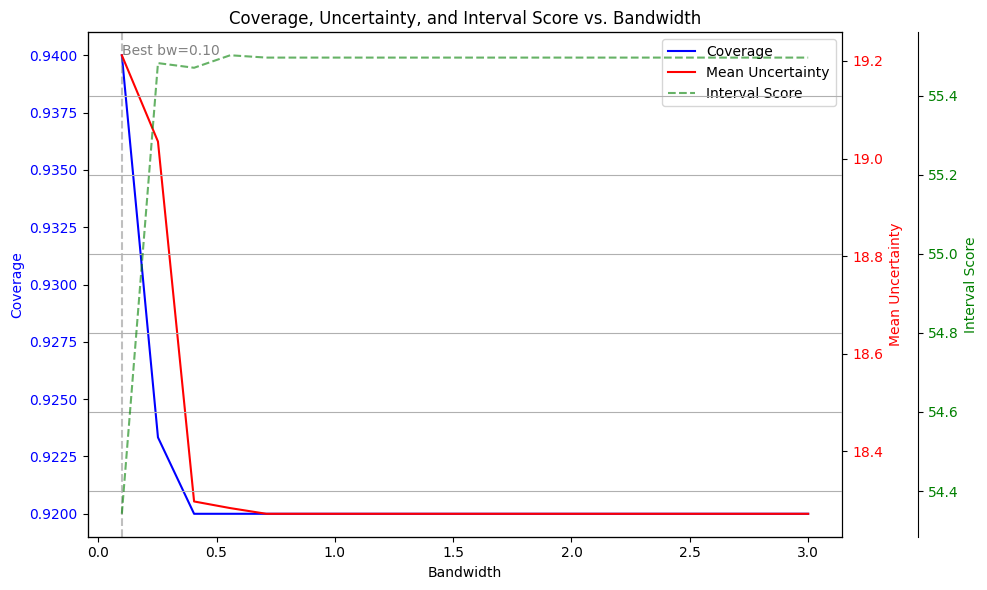

Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 0.100
  Coverage        = 0.940
  Interval Score  = 54.342
  Mean Interval   = 19.212


In [45]:
coverage_list, uncertainty_list, interval_score_list = bandwidth_grid_sweep_geocp(
    bandwidth_list=np.linspace(0.1, 3.0, 20),
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


# LSCP

In [46]:
!pip install quantile_forest

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import LSCP

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def k_grid_sweep_lscp(
    k_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for k in k_list:
        model = LSCP.LSCP(
    predict_f=model_spatial.predict,
    miscoverage_level=alpha,
    k=k,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    x_calib=X_val,
    y_calib=y_val,
    x_test=X_test,
    y_test=y_test
)

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        unc = np.array(result.geo_uncertainty)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)

    # 找出最优 k
    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_k = k_list[best_idx]

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(k_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(k_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(k_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_k, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_k, coverage_list[best_idx], f'Best k={best_k}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('k (Number of Neighbors)')
    plt.title('Coverage, Uncertainty, and Interval Score vs. k')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Best k (Coverage ≥ {coverage_threshold}):")
    print(f"  k               = {best_k}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    return coverage_list, uncertainty_list, interval_score_list


100%|██████████| 300/300 [00:18<00:00, 16.19it/s]


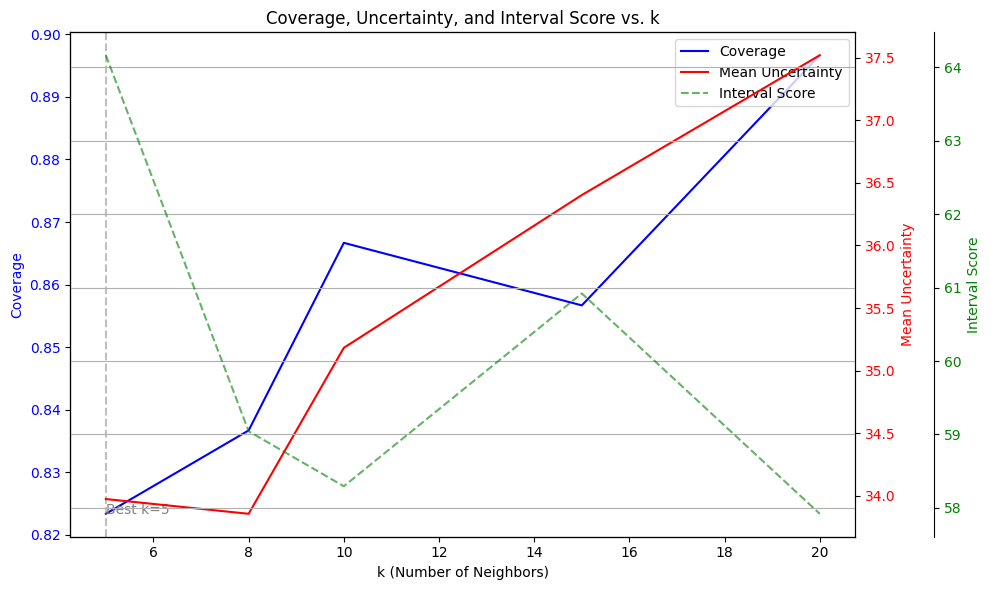

Best k (Coverage ≥ 0.9):
  k               = 5
  Coverage        = 0.823
  Interval Score  = 64.167
  Mean Interval   = 33.973


([np.float64(0.8233333333333334),
  np.float64(0.8366666666666667),
  np.float64(0.8666666666666667),
  np.float64(0.8566666666666667),
  np.float64(0.8966666666666666)],
 [np.float64(33.97318391668583),
  np.float64(33.85531013870275),
  np.float64(35.18185713814213),
  np.float64(36.40248579961237),
  np.float64(37.51991457380022)],
 [np.float64(64.1666791655356),
  np.float64(59.04310299248461),
  np.float64(58.293953146705825),
  np.float64(60.92099804467569),
  np.float64(57.91855954103053)])

In [53]:
k_grid_sweep_lscp(
    k_list=[5, 8, 10, 15, 20],
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


# GeoSIMCP

In [ ]:
## GeoCP
from GeoSIMCP import GeoSIMConformalSpatialRegression

#X_spatial_val = X_spatial_val.astype(float)
#X_spatial_test = X_spatial_test.astype(float)


geosimcp = GeoSIMConformalSpatialRegression(
    predict_f=model_spatial.predict,            # 原模型，含地理特征
    miscoverage_level=0.1,
    bandwidth=0.15,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,                          # 包含经纬度特征
    y_calib=y_val,
    X_test=X_spatial_test,                          # 包含经纬度特征
    y_test=y_test,
    X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
    X_test_weight=X_aspatial_test,
    lambda_weight=0
)

results_geosimcp = geosimcp.analyze()
print("Coverage:", results_geosimcp.coverage_probability)
print("Uncertainty:", results_geosimcp.uncertainty)


In [ ]:
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
      predict_f=model_spatial.predict,            # 原模型，含地理特征
      miscoverage_level=0.1,
      bandwidth=3,
      coord_calib=loc_val.values,
      coord_test=loc_test.values,
      X_calib=X_spatial_val,                          # 包含经纬度特征
      y_calib=y_val,
      X_test=X_spatial_test,                          # 包含经纬度特征
      y_test=y_test,
      X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
      X_test_weight=X_aspatial_test,
      lambda_weight=lam
  )
    result = geosimcp.analyze()
    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)


fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')

ax1.set_ylabel('Coverage', color='b')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax1.set_xlabel('Lambda')

# 合并两个 y 轴的图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title('Coverage and Uncertainty vs. Lambda')
plt.tight_layout()
plt.show()



In [ ]:
X_spatial_val

### interval score

In [ ]:
# 1. 自定义函数
def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


# 2. 主循环中加入 interval_score 评估
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []
interval_score_list = []

alpha = 0.1

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
        predict_f=model_spatial.predict,
        miscoverage_level=alpha,
        bandwidth=3,
        coord_calib=loc_val.values,
        coord_test=loc_test.values,
        X_calib=X_spatial_val,
        y_calib=y_val,
        X_test=X_spatial_test,
        y_test=y_test,
        X_calib_weight=X_aspatial_val,
        X_test_weight=X_aspatial_test,
        lambda_weight=lam
    )

    result = geosimcp.analyze()

    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)

    lower = np.array(result.lower_bound)
    upper = np.array(result.upper_bound)
    y_true = np.array(y_test)

    score = interval_score(y_true, lower, upper, alpha=alpha)
    interval_score_list.append(np.mean(score))




import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Coverage - 蓝色
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax1.set_ylabel('Coverage', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Uncertainty - 红色
ax2 = ax1.twinx()
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Interval Score - 绿色虚线
ax3 = ax1.twinx()
ax3.spines['right'].set_position(("axes", 1.1))
ax3.plot(lambda_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
ax3.set_ylabel('Interval Score', color='g')
ax3.tick_params(axis='y', labelcolor='g')

# 标注最优点（最小 interval score）
best_idx = np.argmin(interval_score_list)
best_lambda = lambda_list[best_idx]
ax1.axvline(x=best_lambda, color='gray', linestyle='--', alpha=0.5)
ax1.text(best_lambda, coverage_list[best_idx], f'Best λ={best_lambda:.2f}', color='gray')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

ax1.set_xlabel('Lambda')
plt.title('Coverage, Uncertainty, and Interval Score vs. Lambda')
plt.grid(True)
plt.tight_layout()
plt.show()


### Optimize Bandwidth

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


def bandwidth_sweep(
    bandwidth_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    lambda_weight=0.5
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for bw in bandwidth_list:
        model = GeoSIMConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_spatial_val,
            y_calib=y_val,
            X_test=X_spatial_test,
            y_test=y_test,
            X_calib_weight=X_aspatial_val,
            X_test_weight=X_aspatial_test,
            lambda_weight=lambda_weight
        )

        result = model.analyze()

        coverage_list.append(result.coverage_probability)
        uncertainty_list.append(result.uncertainty)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        interval_score_list.append(np.mean(score))

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    best_idx = np.argmin(interval_score_list)
    best_bw = bandwidth_list[best_idx]
    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
bandwidth_list = np.linspace(0.1, 5.0, 50)

bandwidth_sweep(
    bandwidth_list=bandwidth_list,
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    lambda_weight=0.5  # 可以固定一个 lambda
)


## 自动选最优

In [ ]:

def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            uncertainty_grid[i, j] = result.uncertainty

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            interval_score_grid[i, j] = np.mean(score)

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    # 可视化 heatmap with masking
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='Blues',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='Reds',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='Greens',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (valid if coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


In [ ]:
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


# GeoSIMCP——zhao2024

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from GeoSIMCP_zhao import GeoSIMZhao2024ConformalSpatialRegression

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMZhao2024ConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            # Use robust mean for uncertainty
            if result.geo_uncertainty is not None:
                valid_uncertainty = np.array(result.geo_uncertainty)
                valid_uncertainty = valid_uncertainty[~np.isnan(valid_uncertainty)]
                uncertainty_grid[i, j] = np.mean(valid_uncertainty) if len(valid_uncertainty) > 0 else np.nan
            else:
                uncertainty_grid[i, j] = np.nan

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            score_filtered = score[~np.isnan(score)]
            interval_score_grid[i, j] = np.mean(score_filtered) if len(score_filtered) > 0 else np.nan

            if np.isnan(interval_score_grid[i, j]):
                print(f"[Warning] NaN interval score at λ={lam:.3f}, bw={bw:.3f}")

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='Blues',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='Reds',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='Greens',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (valid if coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


In [ ]:
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)